In [1]:
# Standard imports
import polars as pl
import numpy as np
import pandas as pd
from pathlib import Path

# LightGBM
import lightgbm as lgb

# Sklearn for calibration and metrics
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression # for Platt scaling
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import OrdinalEncoder

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import time
import joblib

# Paths
TRAIN_PATH = Path("../data/interim/train_split.parquet")
VAL_PATH = Path("../data/interim/val_split.parquet")
MODELS_DIR = Path("../models")

print(f"LightGBM version: {lgb.__version__}")
print(f"Files exist: train={TRAIN_PATH.exists()}, val={VAL_PATH.exists()}")
print(f"Models dir exists: {MODELS_DIR.exists()}")

LightGBM version: 4.3.0
Files exist: train=True, val=True
Models dir exists: True


In [2]:
# Load saved encoder and model
print("Loading saved encoder...")
encoder = joblib.load(MODELS_DIR / "ordinal_encoder.pkl")
print(f"Encoder loaded with {len(encoder.categories_)} categorical columns")

print("\nLoading saved LightGBM model...")
model = lgb.Booster(model_file=str(MODELS_DIR / "lightgbm_final.txt"))
print(f"Model loaded.")
print(f"Number of features: {model.num_feature()}")
print(f"Number of trees: {model.num_trees()}")

Loading saved encoder...
Encoder loaded with 21 categorical columns

Loading saved LightGBM model...
Model loaded.
Number of features: 23
Number of trees: 617


## Loading and preparing val dataset

In [12]:
def add_features(df):
    return (
        df
        .with_columns(pl.col("hour").cast(pl.String).alias("hour_str"))
        .with_columns([
            pl.col("hour_str").str.slice(4,2).cast(pl.Int8).alias("day"),
            pl.col("hour_str").str.slice(6,2).cast(pl.Int8).alias("hour_of_day")
        ])
        .with_columns(((pl.col("day")-21+1) % 7).alias("day_of_week"))
        .with_columns(pl.col("day_of_week").is_in([5,6]).alias("is_weekend"))
        .with_columns((pl.col("app_id") != "ecad2386").alias("is_app"))
        .drop(["hour_str","hour","day","device_ip","device_id","id"])
    )

CATEGORICAL_COLS = [
    "C1", "banner_pos", "device_type", "device_conn_type",
    "C14", "C15", "C16", "C17", "C18", "C19", "C20", "C21",
    "hour_of_day", "day_of_week",
    "site_id", "site_domain", "site_category",
    "app_id", "app_domain", "app_category",
    "device_model",
]

print("Loading val...")
val = add_features(pl.scan_parquet(VAL_PATH)).collect()
print(f"Val shape: {val.shape}")

Loading val...
Val shape: (8051546, 24)


### Preparing X, y

In [16]:
# Separate features and target
y_val = val["click"].to_numpy()
X_val = val.drop("click").to_pandas()

# Apply loaded encoder to categorical columns
X_val[CATEGORICAL_COLS] = encoder.transform(X_val[CATEGORICAL_COLS])

# Convert boolean columns to int8
X_val["is_weekend"] = X_val["is_weekend"].astype("int8")
X_val["is_app"] = X_val["is_app"].astype("int8")

print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print("\nDtypes summary:")
print(X_val.dtypes.value_counts())

X_val shape: (8051546, 23)
y_val shape: (8051546,)

Dtypes summary:
int32    21
int8      2
Name: count, dtype: int64


### Splitting val into cal and new_val sets

In [22]:
# Split val into calibration and new validation sets
np.random.seed(42)

n = len(y_val)
indices = np.random.permutation(n) # for random indexing the data from the previous val set
split_point = n // 2 # splitting the old val set into 2 parts - for new_val and calibration

cal_indices = indices[:split_point]
new_val_indices = indices[split_point:]

X_val_new = X_val.iloc[new_val_indices].reset_index(drop=True) # reset index - new ones start from 0, 1,...
y_val_new = y_val[new_val_indices]

X_cal = X_val.iloc[cal_indices].reset_index(drop=True)
y_cal = y_val[cal_indices]

print(f"Original validation set: {len(y_val):,} rows, CTR = {y_val.mean():.4f}")
print(f"New validation set: {len(y_val_new):,} rows, CTR = {y_val_new.mean():.4f}")
print(f"Calibration set: {len(y_cal):,} rows, CTR = {y_cal.mean():.4f}")

Original validation set: 8,051,546 rows, CTR = 0.1632
New validation set: 4,025,773 rows, CTR = 0.1634
Calibration set: 4,025,773 rows, CTR = 0.1630


### Predictions on cal and new_val

In [24]:
print("Generating predictions on calibration set...")
y_cal_pred_uncal = model.predict(X_cal.values)

print("Generating predictions on new val set...")
y_val_pred_uncal = model.predict(X_val_new.values)

print("\nPredictions from uncalibrated model:")
print(f"   Cal set:       range [{y_cal_pred_uncal.min():.4f},{y_cal_pred_uncal.max():.4f}], mean = {y_cal_pred_uncal.mean():.4f}")
print(f"   New val set:   range [{y_val_pred_uncal.min():.4f},{y_val_pred_uncal.max():.4f}], mean = {y_val_pred_uncal.mean():.4f}")
print("\nActual CTR:")
print(f"   Cal set: {y_cal.mean():.4f}")
print(f"   New val set: {y_val_new.mean():.4f}")

Generating predictions on calibration set...
Generating predictions on new val set...

Predictions from uncalibrated model:
   Cal set:       range [0.0000,0.9864], mean = 0.1675
   New val set:   range [0.0000,0.9868], mean = 0.1675

Actual CTR:
   Cal set: 0.1630
   New val set: 0.1634


# Calibration

### Platt scaling - logistic regresion on model's predictions

In [25]:
print("Training Platt scaler on calibration set...")

# Reshape predictions to 2 dimensions (2D expected for X by sklearn)
y_cal_pred_2d = y_cal_pred_uncal.reshape(-1,1) # -1 for automatic calculation in the first dimension (# of columns)

# Fit Platt scaler (logistic regression on raw predictions)
platt = LogisticRegression()
platt.fit(y_cal_pred_2d, y_cal)

# Apply to new val set
y_val_pred_2d = y_val_pred_uncal.reshape(-1,1)
y_val_pred_platt = platt.predict_proba(y_val_pred_2d)[:,1] # only positive class used

print("Platt-calibrated predictions:")
print(f"   Range:      [{y_val_pred_platt.min():.4f},{y_val_pred_platt.max():.4f}]")
print(f"   Mean:       {y_val_pred_platt.mean():.4f}")
print(f"   Actual CTR: {y_val_new.mean():.4f}")

Training Platt scaler on calibration set...
Platt-calibrated predictions:
   Range:      [0.0482,0.9764]
   Mean:       0.1631
   Actual CTR: 0.1634


In [27]:
print("\nPlatt scaler coefficients:")
print(f"  a (slope): {platt.coef_[0][0]:.4f}")
print(f"  b (intercept): {platt.intercept_[0]:.4f}")


Platt scaler coefficients:
  a (slope): 6.7969
  b (intercept): -2.9829


### Isotonic regression

In [28]:
print("Training isotonic regression on callibration set...")

iso = IsotonicRegression(out_of_bounds = "clip")
iso.fit(y_cal_pred_uncal, y_cal)

# Apply to new val set
y_val_pred_iso = iso.transform(y_val_pred_uncal)

print("Isotonic-calibrated predictions:")
print(f"   Range:      [{y_val_pred_iso.min():.4f},{y_val_pred_iso.max():.4f}]")
print(f"   Mean:       {y_val_pred_iso.mean():.4f}")
print(f"   Actual CTR: {y_val_new.mean():.4f}")

Training isotonic regression on callibration set...
Isotonic-calibrated predictions:
   Range:      [0.0000,1.0000]
   Mean:       0.1631
   Actual CTR: 0.1634


- both methods gave the same CTR
- big difference in ranges - isotonic yields more extreme predictions (may better translate into reality), Platt more conservative

### Metrics

In [30]:
# Compute metrics for all three approaches
log_loss_uncal = log_loss(y_val_new, y_val_pred_uncal)
log_loss_platt = log_loss(y_val_new, y_val_pred_platt)
log_loss_iso = log_loss(y_val_new, y_val_pred_iso)

auc_uncal = roc_auc_score(y_val_new, y_val_pred_uncal)
auc_platt = roc_auc_score(y_val_new, y_val_pred_platt)
auc_iso = roc_auc_score(y_val_new, y_val_pred_iso)

print("METRICS COMPARISON:")
print(f"\n  Uncalibrated (raw model):")
print(f"    Log loss: {log_loss_uncal:.4f}")
print(f"    AUC:      {auc_uncal:.4f}")

print(f"\n  Platt scaling:")
print(f"    Log loss: {log_loss_platt:.4f}")
print(f"    AUC:      {auc_platt:.4f}")

print(f"\n  Isotonic regression:")
print(f"    Log loss: {log_loss_iso:.4f}")
print(f"    AUC:      {auc_iso:.4f}")

METRICS COMPARISON:

  Uncalibrated (raw model):
    Log loss: 0.3890
    AUC:      0.7469

  Platt scaling:
    Log loss: 0.3935
    AUC:      0.7469

  Isotonic regression:
    Log loss: 0.3887
    AUC:      0.7469


- calibration does not change AUC (ranking will stay the same, only values of probabilities change)
- Platt scaler made log loss worse (range narrowed - extreme predictions pushed more into the middle of range) --> higher penalty (loss) for "indecisive" predictions
- isotonic regression have wider range --> lower penalty for more extreme correct predictions

### Conlusion
Isotonic regression is a better choice here: lower log loss, mean prediction in agreement with CTR, doesn't spoil extreme predictions

## Reliability diagram

In [32]:
# Calibration curves for all three approaches
prob_true_uncal, prob_pred_uncal = calibration_curve(
    y_val_new, y_val_pred_uncal, n_bins = 10, strategy = "quantile"
)
prob_true_platt, prob_pred_platt = calibration_curve(
    y_val_new, y_val_pred_platt, n_bins = 10, strategy = "quantile"
)
prob_true_iso, prob_pred_iso = calibration_curve(
    y_val_new, y_val_pred_iso, n_bins = 10, strategy = "quantile"
)

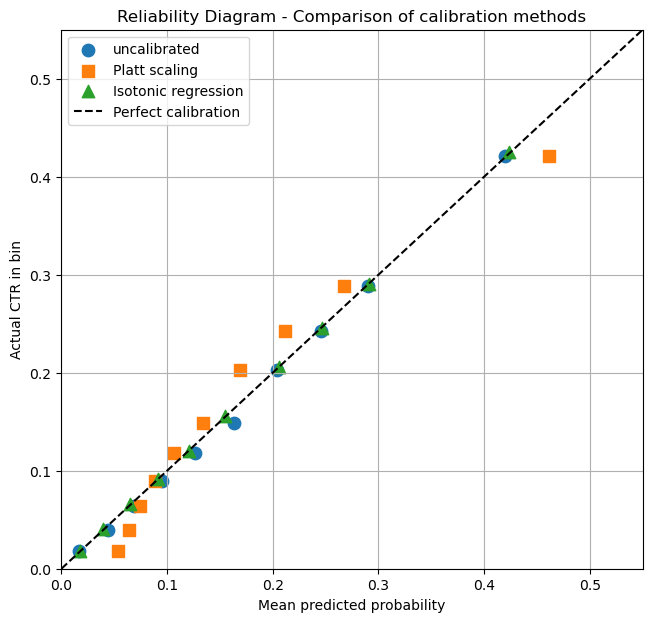

In [35]:
# Plot all three on one figure
plt.figure(figsize=(7.5, 7))

plt.scatter(prob_pred_uncal, prob_true_uncal, s=80, label="uncalibrated", marker="o")
plt.scatter(prob_pred_platt, prob_true_platt, s=80, label="Platt scaling", marker="s")
plt.scatter(prob_pred_iso, prob_true_iso, s=80, label="Isotonic regression", marker="^")

plt.plot([0,1],[0,1], "k--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Actual CTR in bin")
plt.title("Reliability Diagram - Comparison of calibration methods")
plt.legend()
plt.grid(True)
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)

plt.show()

- uncalibrated points close to perfect calibration line - LightGBM was already well calibrated
- Platt scaling systematically drift away from perfect calibration, the highest differences at the lowest and highest values - Platt scaling made predictions worse
- isotonic regression improved the values in the middle range in comparison to uncalibrated, visibly the best result - practically lays on the perfect calibration line, but the uncalibrated model was already good

### Expected Calibration Error

In [36]:
def expected_calibration_error(y_true, y_pred, n_bins=10):
    """
    Compute Expected Calibration Error.

    Arguments: 
        y_true: array of true labels (0 or 1)
        y_pred: array of predicted probabilities
        n_bins: number of bins for grouping predictions

    Returns:
        ECE value (lower is better, 0 is perfect)
    """
    # Create bin edges based on quantiles (same as our reliability diagrams)
    bin_edges = np.quantile(y_pred, np.linspace(0,1,n_bins+1))

    ece = 0.0
    n_total = len(y_true)

    for i in range(n_bins):
        # Find predictions in this bin
        if i < n_bins - 1:
            in_bin = (y_pred >= bin_edges[i]) & (y_pred < bin_edges[i+1])
        else:
            # Last bin includes upper boundary
            in_bin = (y_pred >= bin_edges[i]) & (y_pred <= bin_edges[i+1])

        n_in_bin = in_bin.sum()
        if n_in_bin == 0:
            continue

        # Average prediction and actual frequency in this bin
        avg_pred = y_pred[in_bin].mean()
        avg_true = y_true[in_bin].mean()

        # Weigthed contribution to ECE
        bin_weight = n_in_bin / n_total
        ece += bin_weight * abs(avg_pred - avg_true)

    return ece

In [37]:
ece_uncal = expected_calibration_error(y_val_new, y_val_pred_uncal)
ece_platt = expected_calibration_error(y_val_new, y_val_pred_platt)
ece_iso = expected_calibration_error(y_val_new, y_val_pred_iso)

print("EXPECTED CALIBRATION ERROR (ECE):")
print(f"  Uncalibrated:        {ece_uncal:.4f}")
print(f"  Platt scaling:       {ece_platt:.4f}")
print(f"  Isotonic regression: {ece_iso:.4f}")

EXPECTED CALIBRATION ERROR (ECE):
  Uncalibrated:        0.0045
  Platt scaling:       0.0224
  Isotonic regression: 0.0007


- uncalibrated model was already good: < 0.5 p.p. difference between the predicted and real values
- Platt scaling ~5 times worse than uncalibrated - proven again to be the worst
- Isotonic regression ~6 times better than uncalibrated, virtually perfect calibration, average mismatch between prediction and reality - 0.07 p.p.

#### Saving calibration model

In [38]:
joblib.dump(iso, MODELS_DIR / "isotonic_calibrator.pkl")
print("Isotonic calibrator saved.")

Isotonic calibrator saved.


In [39]:
from pathlib import Path
models_dir = Path("models")
for f in sorted(models_dir.iterdir()):
    if f.suffix in [".txt", ".pkl"]:
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"  {f.name}: {size_mb:.2f} MB")

  isotonic_calibrator.pkl: 0.01 MB
  lightgbm_dart.txt: 9.04 MB
  lightgbm_default.txt: 6.90 MB
  lightgbm_exp2.txt: 10.38 MB
  lightgbm_exp3.txt: 46.80 MB
  lightgbm_final.txt: 20.01 MB
  onehot_encoder.pkl: 0.31 MB
  ordinal_encoder.pkl: 0.31 MB
  sgdclassifier_reg_log.pkl: 0.39 MB


## Reliability diagram - only isotonic vs uncalibrated

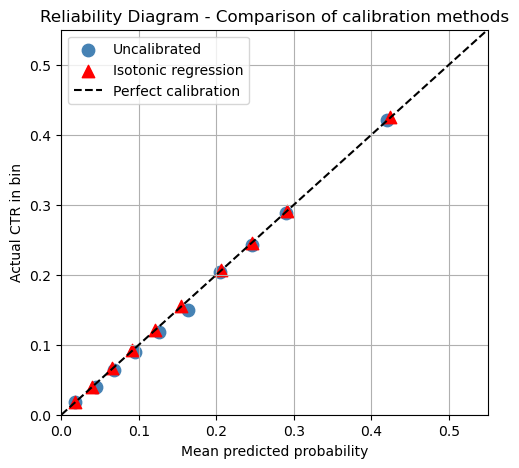

In [45]:
plt.figure(figsize=(5.5,5))

plt.scatter(prob_pred_uncal, prob_true_uncal, s=80, label="Uncalibrated", marker="o", color="steelblue")
plt.scatter(prob_pred_iso, prob_true_iso, s=80, label="Isotonic regression", marker="^", color="red")

plt.plot([0,1],[0,1], "k--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Actual CTR in bin")
plt.title("Reliability Diagram - Comparison of calibration methods")
plt.legend()
plt.grid(True)
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)

plt.show()